In [1]:
SCOPETYPE = 'CWNANO'
PLATFORM = 'CWNANO'
CRYPTO_TARGET='MBEDTLS' 
SS_VER='SS_VER_2_1'

In [2]:
%run "../Setup_Scripts/Setup_Generic.ipynb"

INFO: Found ChipWhisperer😍


In [3]:
%%bash -s "$PLATFORM" "$CRYPTO_TARGET" "$SS_VER"
cd ../../firmware/mcu/simpleserial-aes
make PLATFORM=$1 CRYPTO_TARGET=$2 SS_VER=$3 -j

Building for platform CWNANO with CRYPTO_TARGET=MBEDTLS
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
Blank crypto options, building for AES128
arm-none-eabi-gcc (15:14.2.rel1-1) 14.2.1 20241119
Copyright (C) 2024 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWNANO 
.
Welcome to another exciting ChipWhisperer target build!!
.
.
.
.
.
.
.
.
Compiling:
Compiling:
Compiling:
Compiling:
Compiling:
Compiling:
Assembling: .././hal//stm32f0/stm32f0_startup.S
Compiling:
-en     .././hal//stm32f0_nano/stm32f0_hal_nano.c ...
-en     .././simpleserial/simpleserial.c ...
-en     .././hal/hal.c ...
-en     .././crypto/aes-independant.c ...
arm-none-eabi-gcc -c -mcpu=cortex-m0 -I. -x assembler-with-cpp -mthumb -mfloat-abi=soft -ffunction-sections -DF_CPU=7372800 -Wa,-gstabs,-adhlns=objdir-CWNANO/stm32f0_startup.lst -I.././simpleserial/ -I.././h

In [4]:
cw.program_target(scope, prog, "../../firmware/mcu/simpleserial-aes/simpleserial-aes-{}.hex".format(PLATFORM))

Detected known STMF32: STM32F04xxx
Extended erase (0x44), this can take ten seconds or more
Attempting to program 16075 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 16075 bytes


In [5]:
proj = cw.create_project("Lab 4_3", overwrite=True)

In [6]:
from tqdm.notebook import trange
import numpy as np
import time

ktp = cw.ktp.Basic()
trace_array = []
textin_array = []

N = 1000
for i in trange(N, desc='Capturing traces'):
    key, text = ktp.next()
    trace = cw.capture_trace(scope, target, text, key)
    if not trace:
        continue
    
    proj.traces.append(trace)

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]

In [7]:
scope.dis()
target.dis()

In [8]:
# we can access wave, textin, etc as a whole with proj.traces
for trace in proj.traces:
    print(trace.wave[0], trace.textin, trace.textout, trace.key)

# can also access individually with proj.waves, proj.textins, etc.
for wave in proj.waves:
    print(wave[0])

0.0625 CWbytearray(b'a1 e7 d3 52 1f 8c 61 1c a6 ae eb ca 1b 2e 82 40') CWbytearray(b'35 4a f0 e2 35 b1 6b 21 de d4 be 91 b5 d1 e5 05') CWbytearray(b'2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09 cf 4f 3c')
-0.28515625 CWbytearray(b'85 16 4d bc da c6 66 16 79 22 a6 9c 2f ba e4 ea') CWbytearray(b'20 64 34 01 07 f8 d5 b3 6a ab 93 b8 50 35 f4 7c') CWbytearray(b'2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09 cf 4f 3c')
0.06640625 CWbytearray(b'12 82 bd 21 5b 18 99 0c 27 40 64 7d 7c 0b 92 7d') CWbytearray(b'c7 84 5c 3a 4d 48 9d b5 ef 4d 6b 61 2b e4 18 35') CWbytearray(b'2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09 cf 4f 3c')
-0.14453125 CWbytearray(b'14 df fb 74 ab 93 5f 60 e2 d0 d2 28 fd 8d 0a 4f') CWbytearray(b'c0 5f 40 79 49 4d ca e8 0e 21 fc 6c a7 40 57 ee') CWbytearray(b'2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09 cf 4f 3c')
0.0703125 CWbytearray(b'e2 24 08 ea fe 6e c7 15 c2 be ca 8f 5c 4f cb 43') CWbytearray(b'27 7c a4 6c 6e 6b be 1d 12 24 a9 ee b9 b7 30 f0') CWbytearray(b'2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09

In [9]:
import chipwhisperer.analyzer as cwa

In [10]:
leak_model = cwa.leakage_models.sbox_output

In [11]:
attack = cwa.cpa(proj, leak_model)

In [12]:
print(attack)

project     = <chipwhisperer.common.api.ProjectFormat.Project object at 0x0000028615C75010>
leak_model  = <chipwhisperer.analyzer.attacks.models.AES128_8bit.AES128_8bit object at 0x0000028646A19AF0>
algorithm   = <chipwhisperer.analyzer.attacks.cpa_algorithms.progressive.CPAProgressive object at 0x0000028646A70350>
trace_range = [0, 1000]
point_range = [0, 5000]
subkey_list = range(0, 16)



In [13]:
results = attack.run()

C:\Users\Owner\ChipWhisperer\chipwhisperer\software\chipwhisperer\analyzer\attacks\cpa_algorithms\progressive.py:152: RuntimeWarning: invalid value encountered in divide
  diffs[key] = sumnum / np.sqrt(sumden)


In [14]:
print(results)

Subkey KGuess Correlation
  00    0x2B    0.75628
  01    0x7E    0.73981
  02    0x15    0.80006
  03    0x16    0.68800
  04    0x28    0.74972
  05    0xAE    0.75449
  06    0xD2    0.67243
  07    0xA6    0.70232
  08    0xAB    0.77335
  09    0xF7    0.73765
  10    0x15    0.78715
  11    0x88    0.64959
  12    0x09    0.71280
  13    0xCF    0.72531
  14    0x4F    0.79142
  15    0x3C    0.66306



In [15]:
import pandas as pd
stat_data = results.find_maximums()
df = pd.DataFrame(stat_data).transpose()
print(df.head())

                                0                                1   \
0    [43, 164, 0.7562772692800535]   [126, 291, 0.7398144590105535]   
1   [169, 164, 0.2182444573736489]  [145, 291, 0.18984104570086072]   
2   [32, 150, 0.20973919454223514]    [65, 291, 0.1854282788535961]   
3  [222, 164, 0.19578959610419855]    [208, 292, 0.183014977918644]   
4  [162, 151, 0.19302034702614054]   [64, 292, 0.17534874065980058]   

                               2                                3   \
0   [21, 267, 0.8000621215737427]     [22, 204, 0.688001340313925]   
1  [41, 266, 0.24264257093713817]    [15, 63, 0.20645474787714901]   
2  [156, 266, 0.2347640127999394]   [242, 63, 0.19461727495646788]   
3   [54, 267, 0.2330061461170559]  [153, 205, 0.18302425219528898]   
4  [129, 266, 0.2096009286499162]  [224, 203, 0.18103346263132475]   

                                4                                5   \
0    [40, 198, 0.7497200107532394]   [174, 173, 0.7544881263633907]   
1   [93, 1

In [16]:
key = proj.keys[0]
def format_stat(stat):
    return str("{:02X}<br>{:.3f}".format(stat[0], stat[2]))

def color_corr_key(row):
    global key
    ret = [""] * 16
    for i,bnum in enumerate(row):
        if bnum[0] == key[i]:
            ret[i] = "color: red"
        else:
            ret[i] = ""
    return ret

df.head().style.format(format_stat).apply(color_corr_key, axis=1)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,2B0.756,7E0.740,150.800,160.688,280.750,AE0.754,D20.672,A60.702,AB0.773,F70.738,150.787,880.650,090.713,CF0.725,4F0.791,3C0.663
1,A90.218,910.190,290.243,0F0.206,5D0.211,870.197,460.227,1B0.231,620.245,340.232,E00.212,8B0.206,8B0.236,220.218,440.235,B60.227
2,200.210,410.185,9C0.235,F20.195,A10.203,030.189,270.204,2F0.206,7D0.227,210.182,D40.205,0A0.204,430.233,F00.213,590.215,CA0.203
3,DE0.196,D00.183,360.233,990.183,AA0.195,5B0.183,ED0.184,1D0.202,130.226,3E0.182,900.195,5E0.199,9D0.207,980.198,F40.200,EA0.202
4,A20.193,400.175,810.210,E00.181,CF0.190,910.183,6F0.176,D30.195,940.220,4F0.181,890.191,BB0.194,330.201,4D0.198,040.185,000.196


In [17]:
from IPython.display import clear_output
import numpy as np
        
def stats_callback():
    results = attack.results
    results.set_known_key(key)
    stat_data = results.find_maximums()
    df = pd.DataFrame(stat_data).transpose()
    clear_output(wait=True)
    display(df.head().style.format(format_stat).apply(color_corr_key,axis=1))
    
results = attack.run(stats_callback, 10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,2B0.756,7E0.740,150.800,160.688,280.750,AE0.754,D20.672,A60.702,AB0.773,F70.738,150.787,880.650,090.713,CF0.725,4F0.791,3C0.663
1,A90.218,910.190,290.243,0F0.206,5D0.211,870.197,460.227,1B0.231,620.245,340.232,E00.212,8B0.206,8B0.236,220.218,440.235,B60.227
2,200.210,410.185,9C0.235,F20.195,A10.203,030.189,270.204,2F0.206,7D0.227,210.182,D40.205,0A0.204,430.233,F00.213,590.215,CA0.203
3,DE0.196,D00.183,360.233,990.183,AA0.195,5B0.183,ED0.184,1D0.202,130.226,3E0.182,900.195,5E0.199,9D0.207,980.198,F40.200,EA0.202
4,A20.193,400.175,810.210,E00.181,CF0.190,910.183,6F0.176,D30.195,940.220,4F0.181,890.191,BB0.194,330.201,4D0.198,040.185,000.196


In [18]:
import chipwhisperer as cw
cb = cwa.get_jupyter_callback(attack)
results = attack.run(cb, 10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
PGE=,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,2B0.756,7E0.740,150.800,160.688,280.750,AE0.754,D20.672,A60.702,AB0.773,F70.738,150.787,880.650,090.713,CF0.725,4F0.791,3C0.663
1,A90.218,910.190,290.243,0F0.206,5D0.211,870.197,460.227,1B0.231,620.245,340.232,E00.212,8B0.206,8B0.236,220.218,440.235,B60.227
2,200.210,410.185,9C0.235,F20.195,A10.203,030.189,270.204,2F0.206,7D0.227,210.182,D40.205,0A0.204,430.233,F00.213,590.215,CA0.203
3,DE0.196,D00.183,360.233,990.183,AA0.195,5B0.183,ED0.184,1D0.202,130.226,3E0.182,900.195,5E0.199,9D0.207,980.198,F40.200,EA0.202
4,A20.193,400.175,810.210,E00.181,CF0.190,910.183,6F0.176,D30.195,940.220,4F0.181,890.191,BB0.194,330.201,4D0.198,040.185,000.196


In [19]:
plot_data = cwa.analyzer_plots(results)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
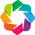

Invoked as dynamic_operation(x_range=None, y_range=None)
Invoked as dynamic_operation(x_range=None, y_range=None)


TypeError: cannot do slice indexing on RangeIndex with these indexers [0.0] of type float64

:Overlay
   .Curve.I      :DynamicMap   []
      :Curve   [Sample]   (0)
   .Curve.II     :DynamicMap   []
   .Curve.III    :DynamicMap   []
   .Curve.IV     :DynamicMap   []
   .Curve.V      :DynamicMap   []
   .Curve.VI     :DynamicMap   []
   .Curve.VII    :DynamicMap   []
   .Curve.VIII   :DynamicMap   []
   .Curve.IX     :DynamicMap   []
   .Curve.X      :DynamicMap   []
   .Curve.XI     :DynamicMap   []
   .Curve.XII    :DynamicMap   []
   .Curve.XIII   :DynamicMap   []
   .Curve.XIV    :DynamicMap   []
   .Curve.XV     :DynamicMap   []
   .Curve.XVI    :DynamicMap   []
   .Curve.XVII   :DynamicMap   []
   .Curve.XVIII  :DynamicMap   []
   .Curve.XIX    :DynamicMap   []
   .Curve.XX     :DynamicMap   []
   .Curve.XXI    :DynamicMap   []
   .Curve.XXII   :DynamicMap   []
   .Curve.XXIII  :DynamicMap   []
   .Curve.XXIV   :DynamicMap   []
   .Curve.XXV    :DynamicMap   []
   .Curve.XXVI   :DynamicMap   []
   .Curve.XXVII  :DynamicMap   []
   .Curve.XXVIII :DynamicMap   []
   .Curve

In [20]:
def byte_to_color(idx):
    return hv.Palette.colormaps['Category20'](idx/16.0)

import holoviews as hv
from holoviews.operation.datashader import datashade, shade, dynspread, rasterize
from holoviews.operation import decimate
import pandas as pd, numpy as np

a = []
b = []
hv.extension('bokeh')
for i in range(0, 16):
    data = plot_data.output_vs_time(i)
    a.append(np.array(data[1]))
    b.append(np.array(data[2]))
    b.append(np.array(data[3]))
    
pda = pd.DataFrame(a).transpose().rename(str, axis='columns')
pdb = pd.DataFrame(b).transpose().rename(str, axis='columns')
curve = hv.Curve(pdb['0'], "Sample").options(color='black')
for i in range(1, 16):
    curve *= hv.Curve(pdb[str(i)]).options(color='black')
    
for i in range(0, 16):
    curve *= hv.Curve(pda[str(i)]).options(color=byte_to_color(i))
decimate(curve.opts(width=900, height=600))

In [21]:
ret = plot_data.pge_vs_trace(0)
curve = hv.Curve((ret[0],ret[1]), "Traces Used in Calculation", "Partial Guessing Entrop of Byte")
for bnum in range(1, 16):
    ret = plot_data.pge_vs_trace(bnum)
    curve *= hv.Curve((ret[0],ret[1])).opts(color=byte_to_color(bnum))
curve.opts(width=900, height=600)

:Overlay
   .Curve.I    :Curve   [Traces Used in Calculation]   (Partial Guessing Entrop of Byte)
   .Curve.II   :Curve   [x]   (y)
   .Curve.III  :Curve   [x]   (y)
   .Curve.IV   :Curve   [x]   (y)
   .Curve.V    :Curve   [x]   (y)
   .Curve.VI   :Curve   [x]   (y)
   .Curve.VII  :Curve   [x]   (y)
   .Curve.VIII :Curve   [x]   (y)
   .Curve.IX   :Curve   [x]   (y)
   .Curve.X    :Curve   [x]   (y)
   .Curve.XI   :Curve   [x]   (y)
   .Curve.XII  :Curve   [x]   (y)
   .Curve.XIII :Curve   [x]   (y)
   .Curve.XIV  :Curve   [x]   (y)
   .Curve.XV   :Curve   [x]   (y)
   .Curve.XVI  :Curve   [x]   (y)

In [22]:
a = []
b = []
for bnum in range(0, 16):
    data = plot_data.corr_vs_trace(bnum)
    best = [0] * len(data[1][0])
    for i in range(256):
        if i == key[bnum]:
            a.append(np.array(data[1][i]))
        else:
            if max(best) < max(data[1][i]): best = data[1][i]
    b.append(np.array(best))

pda = pd.DataFrame(a).transpose().rename(str, axis='columns')
pdb = pd.DataFrame(b).transpose().rename(str, axis='columns')
curve = hv.Curve(pdb['0'].tolist(), "Iteration Number", "Max Correlation").options(color='black')
for i in range(1,len(pdb.columns)):
    curve *= hv.Curve(pdb[str(i)]).options(color='black')
    
for i in range(len(pda.columns)):
    curve *= hv.Curve(pda[str(i)]).options(color=byte_to_color(i))
            
curve.opts(width=900, height=600)

:Overlay
   .Curve.I      :Curve   [Iteration Number]   (Max Correlation)
   .Curve.II     :Curve   [index]   (1)
   .Curve.III    :Curve   [index]   (2)
   .Curve.IV     :Curve   [index]   (3)
   .Curve.V      :Curve   [index]   (4)
   .Curve.VI     :Curve   [index]   (5)
   .Curve.VII    :Curve   [index]   (6)
   .Curve.VIII   :Curve   [index]   (7)
   .Curve.IX     :Curve   [index]   (8)
   .Curve.X      :Curve   [index]   (9)
   .Curve.XI     :Curve   [index]   (10)
   .Curve.XII    :Curve   [index]   (11)
   .Curve.XIII   :Curve   [index]   (12)
   .Curve.XIV    :Curve   [index]   (13)
   .Curve.XV     :Curve   [index]   (14)
   .Curve.XVI    :Curve   [index]   (15)
   .Curve.XVII   :Curve   [index]   (0)
   .Curve.XVIII  :Curve   [index]   (1)
   .Curve.XIX    :Curve   [index]   (2)
   .Curve.XX     :Curve   [index]   (3)
   .Curve.XXI    :Curve   [index]   (4)
   .Curve.XXII   :Curve   [index]   (5)
   .Curve.XXIII  :Curve   [index]   (6)
   .Curve.XXIV   :Curve   [index]   (7)
   .Curve.XXV    :Curve   [index]   (8)
   .Curve.XXVI   :Curve   [index]   (9)
   .Curve.XXVII  :Curve   [index]   (10)
   .Curve.XXVIII :Curve   [index]   (11)
   .Curve.XXIX   :Curve   [index]   (12)
   .Curve.XXX    :Curve   [index]   (13)
   .Curve.XXXI   :Curve   [index]   (14)
   .Curve.XXXII  :Curve   [index]   (15)